# Linear Regression From Scratch 

This notebook implements simple linear regression from first principles using batch gradient descent. It fits a model h(x) = w*x + b by minimizing the mean squared error (MSE) between predictions and targets. Key steps:
- Formulate the loss: MSE = (1/n) * Σ(h(x_i) - y_i)^2
- Compute gradients ∂L/∂w and ∂L/∂b
- Update parameters with gradient descent: w ← w - α * ∂L/∂w, b ← b - α * ∂L/∂b
- Tune learning rate α and number of iterations to ensure convergence
- Evaluate results with MSE (and optionally R²) and visualize the fitted line vs. data

This provides a clear, didactic view of how linear models are optimized without using high-level libraries.


---

##  Dataset Overview


### Context:
The Boston house-price data of Harrison, D. and Rubinfeld, D.L. 'Hedonic prices and the demand for clean air', J. Environ. Economics & Management, vol.5, 81-102, 1978.

### Attribute Information
Input features in order:
1) CRIM: per capita crime rate by town
2) ZN: proportion of residential land zoned for lots over 25,000 sq.ft.
3) INDUS: proportion of non-retail business acres per town
4) CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
5) NOX: nitric oxides concentration (parts per 10 million) [parts/10M]
6) RM: average number of rooms per dwelling
7) AGE: proportion of owner-occupied units built prior to 1940
8) DIS: weighted distances to five Boston employment centres
9) RAD: index of accessibility to radial highways
10) TAX: full-value property-tax rate per $10,000 [$/10k]
11) PTRATIO: pupil-teacher ratio by town
12) B: The result of the equation B=1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13) LSTAT: % lower status of the population

### Output variable:
1) MEDV: Median value of owner-occupied homes in $1000's [k$]

## 1. Import Libraries

In [603]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [604]:
# Utils 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Model Evaluation 
from sklearn.metrics import  (mean_absolute_error , 
                              mean_squared_error , 
                              root_mean_squared_error,
                              r2_score)



## 2. Loading Data 

In [605]:
# Dataset used boston house pricing 
df = pd.read_csv("boston.csv")

# dataset preivew 
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 3. Exploring Data 

In [606]:
# Info of the data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [607]:
# Statistical Summary 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [608]:
# Null value analysis 
df.isna().sum().sum()

np.int64(0)

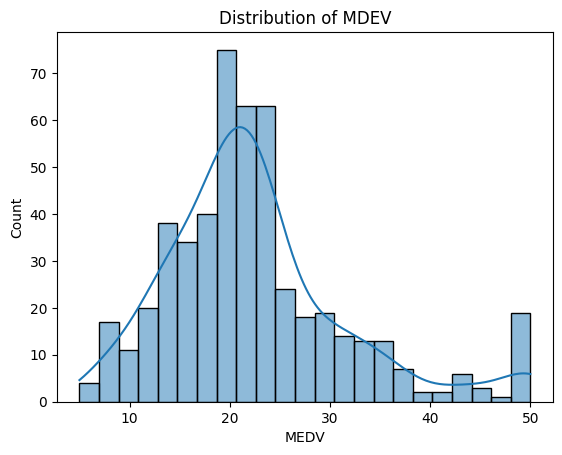

In [609]:
# Distribution of target variable 
sns.histplot(df["MEDV"] , kde = True)
plt.title("Distribution of MDEV")
plt.show()

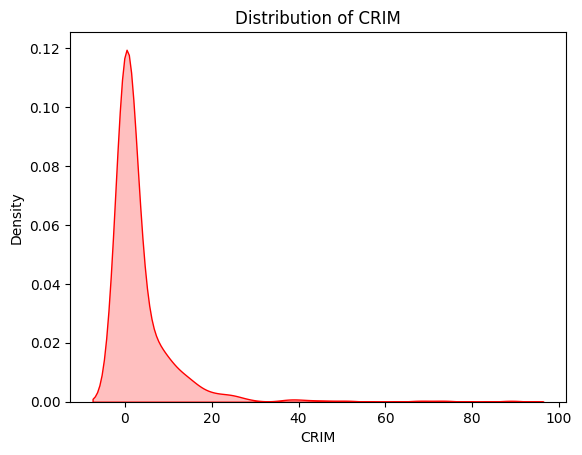

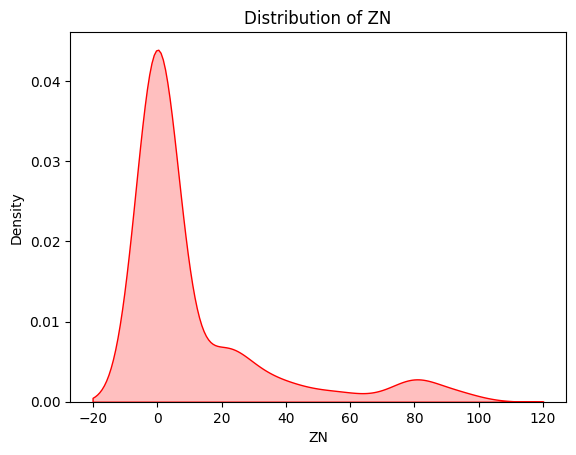

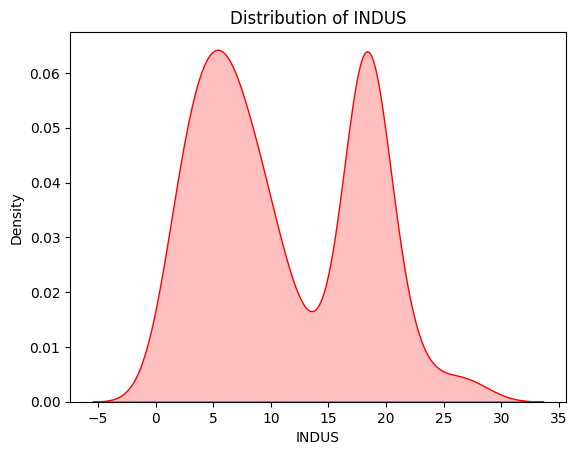

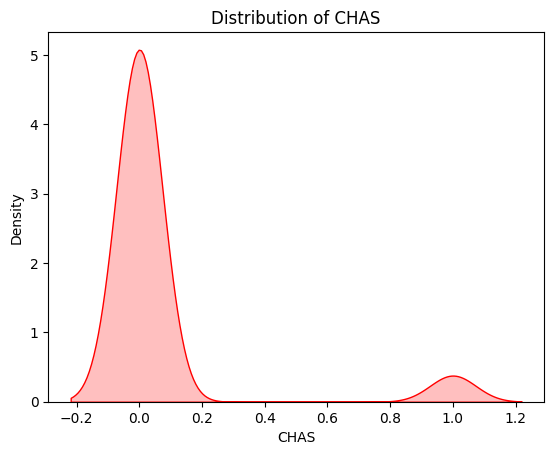

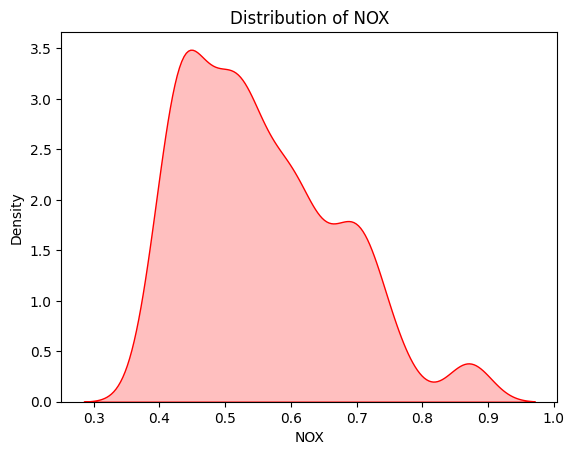

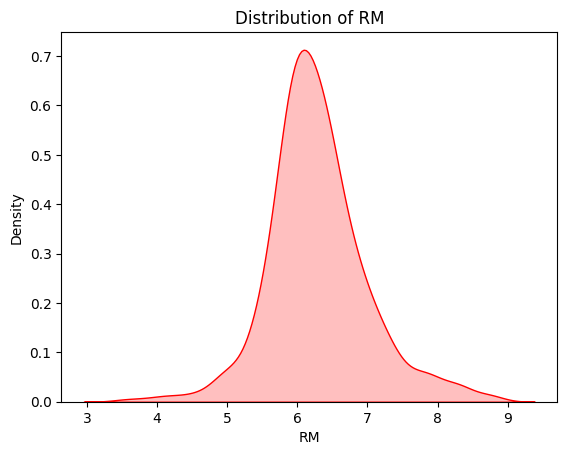

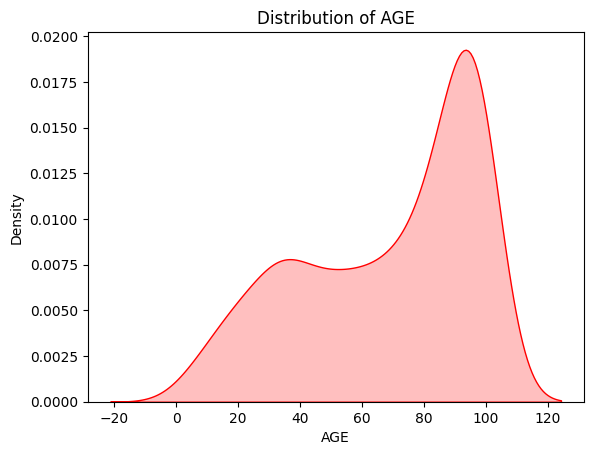

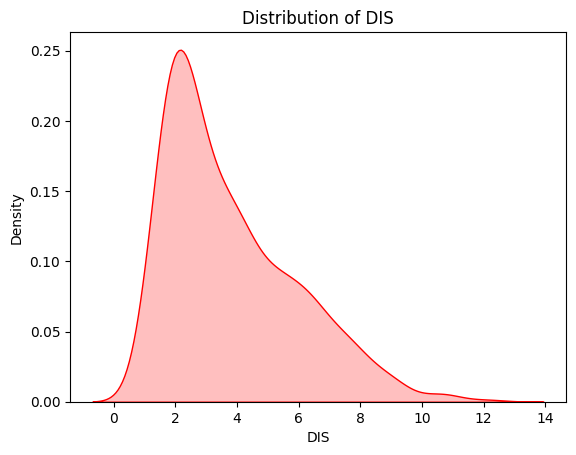

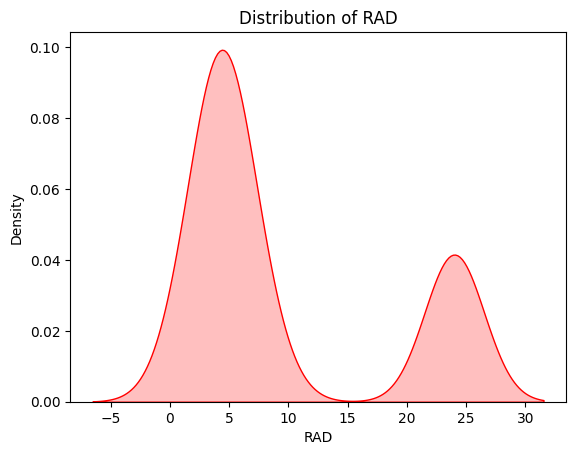

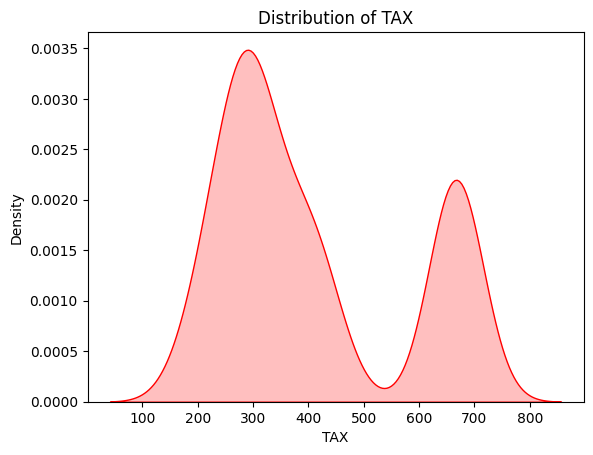

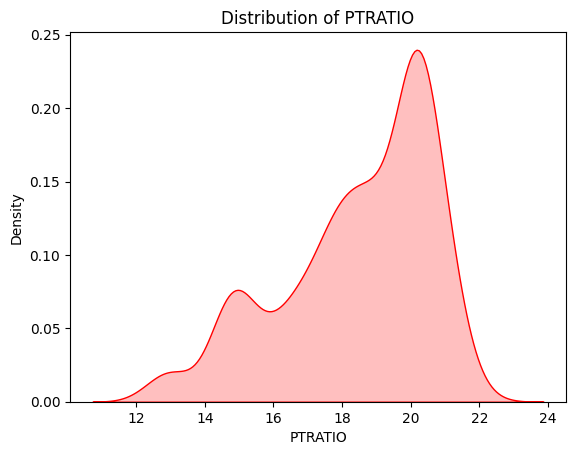

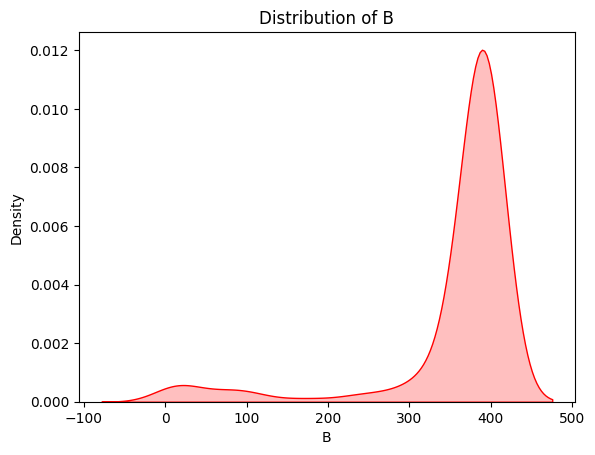

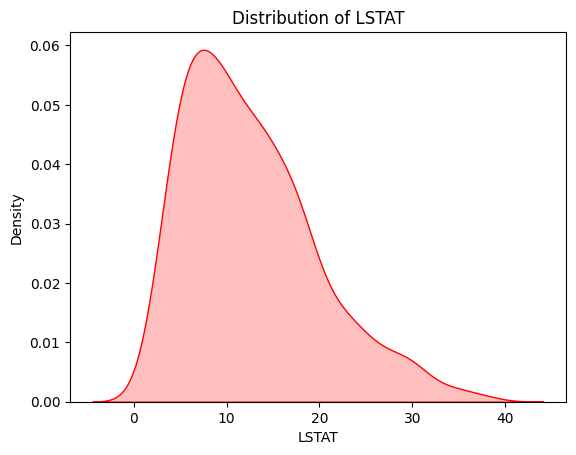

In [610]:
for col in df.columns[:-1]:
    plt.title(f"Distribution of {col}")
    sns.kdeplot(df[col] , fill=True , color = "red")
    plt.show()

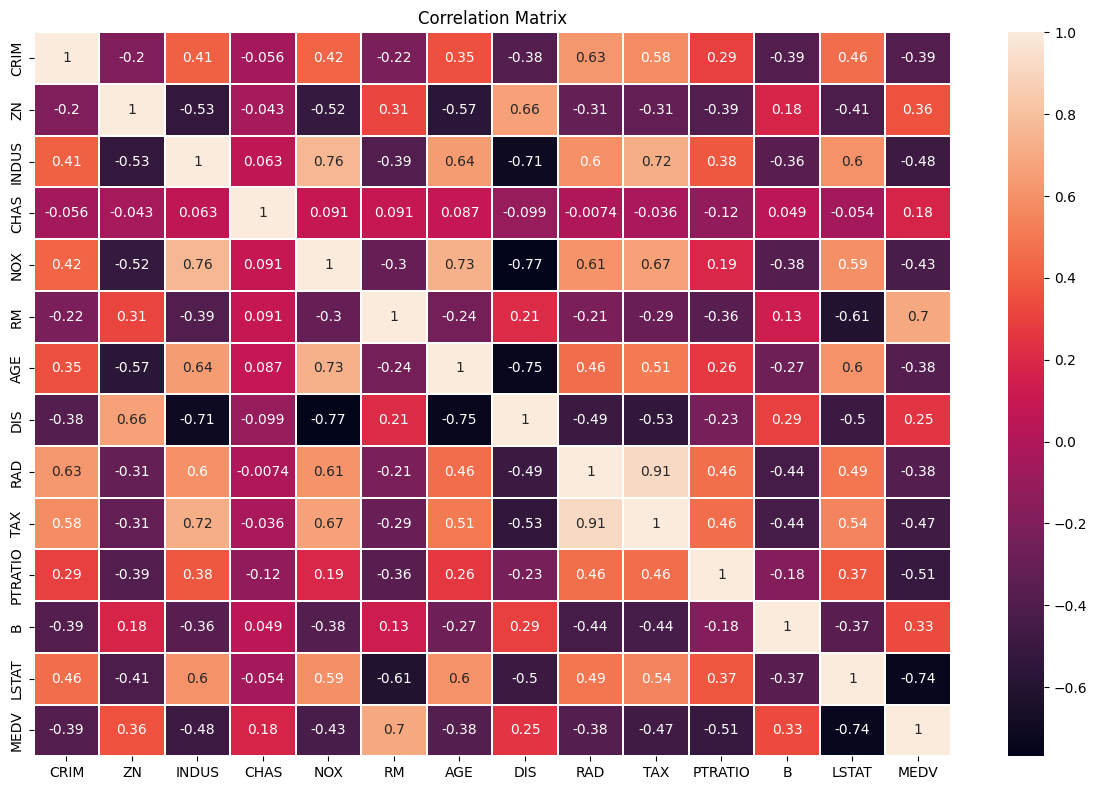

In [611]:
# Correlation matrix 
plt.figure(figsize=(12 , 8))
sns.heatmap(df.corr() , annot=True, linewidths=0.3)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Model Building 


In [612]:
# Spliting X , y 
X = df.iloc[: , :-1]
y = df["MEDV"]

X_train , X_test , y_train , y_test = train_test_split(X  , y , test_size=0.2 , random_state= 424)

In [613]:
# Size of Train , Test data 
# Train 
print("Train")
print("Features Shpae :" , X_train.shape)
print("Label Shape :", y_train.shape )
# Test
print("\nTest")
print("Features Shpae :" , X_test.shape)
print("Label Shape :", y_test.shape )

Train
Features Shpae : (404, 13)
Label Shape : (404,)

Test
Features Shpae : (102, 13)
Label Shape : (102,)


In [614]:
# Model 
# Linear regression from scratch Using Gradient Decsent
class Linear_Regression():

    def __init__(self , learning_rate , no_of_iterations):
    
        self.learning_rate = learning_rate 
        self.no_of_iterations = no_of_iterations

    
    def fit(self , X , y): 
        
        # Total Size and No.of Features (X)
        self.m  , self.n = X.shape
        
        # Initializing the weights (w - slope) and bias (b - intercept)
        self.w = np.zeros(self.n)
        self.b = 0 
        self.X = X 
        self.y = y

        # Initiating GD
        for i in range(self.no_of_iterations):
            self.update_weights()


    def update_weights(self):
        
        y_prediction = self.predict(self.X) # prediction of training sample 

        dw = -(2 * (self.X.T).dot(self.y - y_prediction)) / self.m # weights
        db = -2 * np.sum(self.y - y_prediction) / self.m  # bias

         # Updating weights and bais 
        self.w = self.w - (self.learning_rate * dw) # updating weights 
        self.b = self.b  - (self.learning_rate * db) # updating bias

    def predict(self , X):
        # prediction (y) = X.dot(slope) + intercept
        return X.dot(self.w) + self.b


In [615]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)
X_train

array([[-0.4068458 ,  0.96661578, -1.33972438, ..., -0.01073716,
         0.39687734, -0.801354  ],
       [ 1.24256072, -0.48559535,  1.00343257, ...,  0.81990819,
         0.27999614,  0.06845696],
       [ 0.24617181, -0.48559535,  1.00343257, ...,  0.81990819,
         0.38999533, -0.68734965],
       ...,
       [-0.40858317,  3.03491647, -1.43686531, ..., -2.68726108,
         0.43320528, -1.20248041],
       [-0.29147034, -0.48559535, -0.46251236, ...,  1.1890839 ,
         0.31982149, -0.85061514],
       [ 0.05328601, -0.48559535,  1.00343257, ...,  0.81990819,
         0.41549259,  0.03467789]])

In [616]:
# Model 
model = Linear_Regression(learning_rate= 0.01 , no_of_iterations = 1000)
model.fit(X_train , y_train.values)
y_pred = model.predict(X_test)
y_pred

array([18.55860136, 31.44961556, 17.87479236, 16.40016111, 22.58156716,
       26.33130452, 40.43620488, 37.79605892, 13.94348891, 18.11182955,
       24.97719193, 19.49126776, 20.1853512 , 13.28019866, 26.40442968,
       17.06518761, 23.87184661, 11.74151913, 23.90371866, 17.33706393,
       25.87242092, 22.90723422, 21.17772275, 29.00533607, 18.62374959,
       33.17532042, 23.641895  , 25.64469558, 20.92298628, 16.10646533,
       19.87292129, 15.62831508, 19.92677615, 24.32715333, 16.0567682 ,
       21.76753909, 26.35847599, 30.92439471, 27.95415516, 15.24330787,
       18.89419095, 15.53624093, 11.8040027 , 30.20600606, 26.30760349,
       23.63930921, 31.5643633 ,  0.12377091, 23.30695203, 22.70947298,
       23.76739545, 28.5996808 , 17.71633141, 22.18225376, 17.2846651 ,
       16.99463967,  1.7627389 ,  9.29029242, 26.40982913, 29.3404695 ,
       31.52054724, 17.45228214, 19.1123505 , 21.17555236, 22.38404832,
       31.64752556, 28.35960553, 18.07456811, 25.33369644, 20.98

## 5. Model Evaluation

In [617]:
# Evaluation metrics
print("MAE :" , mean_absolute_error(y_test , y_pred))
print("MSE :" , mean_squared_error(y_test , y_pred))
print("RMSE :" , root_mean_squared_error(y_test , y_pred))
print("r2 Score :" , r2_score(y_test , y_pred))

MAE : 3.2989193576050893
MSE : 19.959498912569323
RMSE : 4.467605501000432
r2 Score : 0.7427567998249021


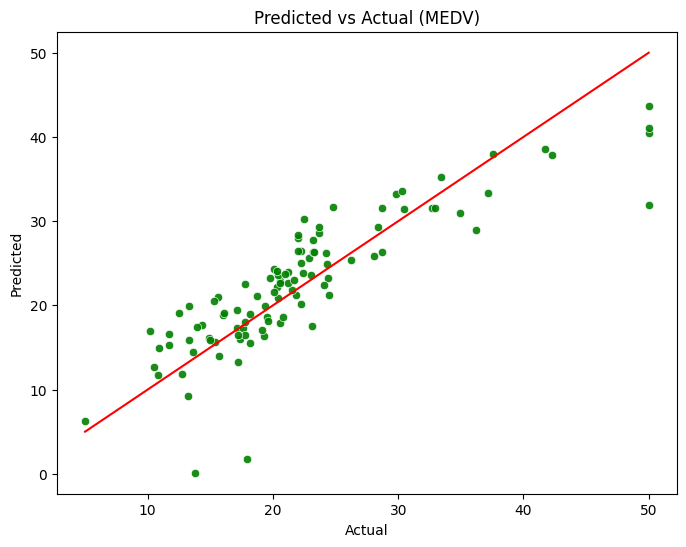

In [618]:
# Line of Best fit
plt.figure(figsize = (8 , 6))
sns.scatterplot(x = y_test , y = y_pred ,alpha = 0.9 , color="Green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")  
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (MEDV)")
plt.show() 

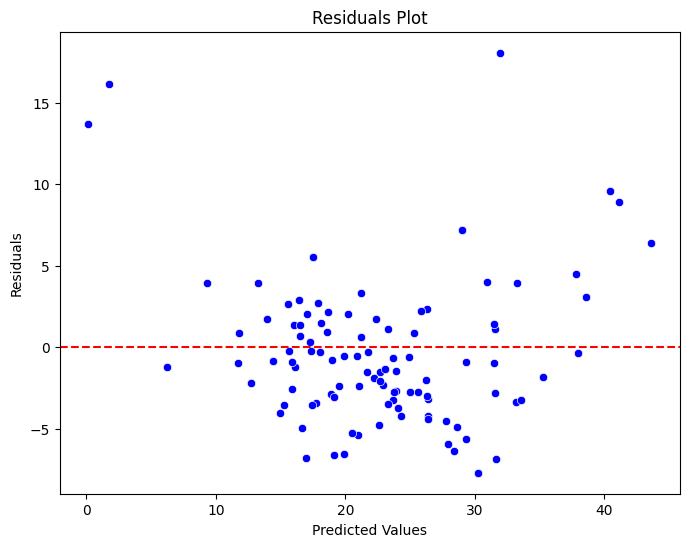

In [619]:
 # residuals 
residual = y_test - y_pred
plt.figure(figsize = (8 , 6))
sns.scatterplot(x = y_pred , y = residual , color = 'blue')
plt.axhline(y = 0 , color = "red" , linestyle = "--" )
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals Plot")
plt.show()